In [3]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

PREPROC_PATH = '/sdf/data/lcls/ds/tmo/tmol1043723/scratch/preproc/vjtw/run99_vjtw.h5'
RIVER_PATH   = '/sdf/data/lcls/ds/tmo/tmol1043723/results/streaking_results/run[99]_vjtw_river.h5'

HSD_CHANNELS = [0, 22, 45, 67, 90, 112, 135, 157,
                180, 202, 225, 247, 270, 292, 315, 337]

In [4]:
# Load river (streaking-results) file — small, load fully.
with h5py.File(RIVER_PATH, 'r') as rf:
    duck_ts    = rf['duck_timestamps'][:]
    duck_kamp  = rf['duck_kamp'][:]
    duck_kangle = rf['duck_kangle'][:]
    goose_ts    = rf['goose_timestamps'][:]
    goose_kamp  = rf['goose_kamp'][:]
    goose_kangle = rf['goose_kangle'][:]

print(f'duck shots:  {duck_ts.size}')
print(f'goose shots: {goose_ts.size}')

duck shots:  26221
goose shots: 2191


In [5]:
# Map duck timestamps -> row indices in the preproc file.
with h5py.File(PREPROC_PATH, 'r') as pf:
    preproc_ts = pf['timestamp'][:]

# Sort-based intersect: fast and vectorized.
sort_idx = np.argsort(preproc_ts)
sorted_ts = preproc_ts[sort_idx]
pos = np.searchsorted(sorted_ts, duck_ts)

hit = (pos < sorted_ts.size) & (sorted_ts[np.clip(pos, 0, sorted_ts.size - 1)] == duck_ts)
duck_rows = sort_idx[pos[hit]]           # row index into preproc arrays
duck_river_idx = np.flatnonzero(hit)     # matching index into duck_* arrays

# Keep both sides ordered by preproc row for efficient h5 reads.
order = np.argsort(duck_rows)
duck_rows = duck_rows[order]
duck_river_idx = duck_river_idx[order]

print(f'duck shots matched to preproc rows: {duck_rows.size} / {duck_ts.size}')

duck shots matched to preproc rows: 26221 / 26221


In [6]:
# Reconstruct variable-length HSD hi-freq times per duck shot, per channel.
# Layout in-file: one flat float64 array + a per-event length array (same rows as timestamp).
# Row i occupies flat[starts[i]:starts[i]+lens[i]] where starts = cumsum(lens) - lens.
#
# The previous version sliced the h5 dataset ~26k times per channel (~420k
# reads total). Read `flat` and `lens` into memory once per channel (each
# channel is ~50-100 MB float64 -> fine) and slice numpy arrays instead.
def load_hsd_channel(pf, ch, rows):
    lens = pf[f'var_hsd_hf_times_{ch}_len'][:]        # (N_events,)
    flat = pf[f'var_hsd_hf_times_{ch}'][:]            # read whole channel once
    ends = np.cumsum(lens)
    starts = ends - lens
    return [flat[starts[r]:ends[r]] for r in rows]    # views into `flat`

with h5py.File(PREPROC_PATH, 'r') as pf:
    duck_hsd = {ch: load_hsd_channel(pf, ch, duck_rows) for ch in HSD_CHANNELS}

# Sanity check on one channel.
ch = HSD_CHANNELS[0]
lengths = np.array([a.size for a in duck_hsd[ch]])
print(f'channel {ch}: {len(duck_hsd[ch])} shots, hits/shot min={lengths.min()} max={lengths.max()} mean={lengths.mean():.2f}')

channel 0: 26221 shots, hits/shot min=2 max=43 mean=16.12


In [7]:
# Pull per-duck-shot scalars + fzp spectra from the preproc file.
# h5py fancy indexing needs a *sorted*, unique index list (duck_rows already is).
with h5py.File(PREPROC_PATH, 'r') as pf:
    duck_gmd    = pf['gmd_energy'][duck_rows]
    duck_xgmd   = pf['xgmd_energy'][duck_rows]
    duck_scan0  = pf['scan_var_0'][duck_rows]
    duck_fzp    = pf['fzp'][duck_rows, :]        # (N_duck, 2048)

# Re-align the river-side arrays to the same row order.
duck_kamp_matched   = duck_kamp[duck_river_idx]
duck_kangle_matched = duck_kangle[duck_river_idx]
duck_ts_matched     = duck_ts[duck_river_idx]

print(f'fzp:   {duck_fzp.shape}')
print(f'gmd:   {duck_gmd.shape}, mean={duck_gmd.mean():.3g}')
print(f'kamp:  {duck_kamp_matched.shape}, mean={duck_kamp_matched.mean():.3g}')

fzp:   (26221, 2048)
gmd:   (26221,), mean=19
kamp:  (26221,), mean=0.00726


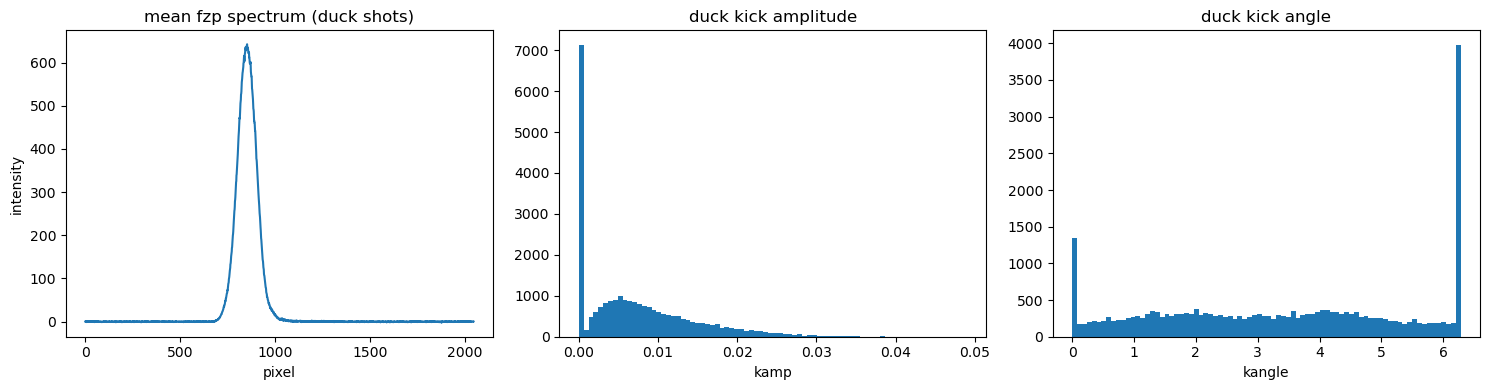

In [8]:
# Quick look: mean fzp spectrum over duck shots + kick amplitude/angle distributions.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(duck_fzp.mean(axis=0))
axes[0].set_title('mean fzp spectrum (duck shots)')
axes[0].set_xlabel('pixel'); axes[0].set_ylabel('intensity')

axes[1].hist(duck_kamp_matched, bins=80)
axes[1].set_title('duck kick amplitude'); axes[1].set_xlabel('kamp')

axes[2].hist(duck_kangle_matched, bins=80)
axes[2].set_title('duck kick angle'); axes[2].set_xlabel('kangle')

plt.tight_layout()
plt.show()

In [9]:
# Config for ToF -> KE conversion.
# Calibration file: mrco_calib_tmox101_205-213_simon_t0.h5 (flat layout,
# v_r sampled at [0, 50, 100, 150, 175] V).
#
# Sign convention (see tmo_utils.mrco_t2e.MRCOT2P.__init__):
#     KE_returned = KE_at_IP - v_ret
# so v_ret is the retardation *magnitude in eV that the electron loses*
# crossing the mesh. Back mesh at -280 V (eLog) accelerates the ionization
# electrons out of the interaction region toward the detector by 280 eV,
# i.e. it LOWERS the KE we measure by 280 eV. In this convention:
V_RET = 280.0                  # retardation magnitude, eV.
#
# v_ret = 280 is 60% past the calibration endpoint (175 V) — alphas are
# extrapolated. Cross-check per port before trusting the absolute KE axis.

CALIB_PATH = '/sdf/home/m/miaed/copied_ipynbs/tmo_utils/calibration/mrco_calib_tmox101_205-213_simon_t0.h5'
NBINS = 512
ESTEP = 0.1                    # eV / bin

# KE window: 512 bins @ 0.1 eV = 51.2 eV wide. Anchor the RIGHT edge at
# 43.11 eV — that's where the old 0.25 eV/bin grid's bin 320 sat, and
# inspection showed essentially no hits past that point. Shifting left
# preserves as much of the left tail as possible while keeping the full
# ROI (KE_det = 14.19-40.04 eV) in view.
E_AU  = 27.2114                # eV per hartree
P_ROI = (4.65, 4.85)           # sample-frame momentum ROI (a.u.)
P_ROI_KE_IP_LO  = P_ROI[0]**2 / 2 * E_AU
P_ROI_KE_IP_HI  = P_ROI[1]**2 / 2 * E_AU
P_ROI_KE_DET_LO = P_ROI_KE_IP_LO - V_RET
P_ROI_KE_DET_HI = P_ROI_KE_IP_HI - V_RET
KE_CENTER_DET   = 0.5 * (P_ROI_KE_DET_LO + P_ROI_KE_DET_HI)

EMAX = 43.11                   # right edge, aligned with old bin-320 KE
EMIN = EMAX - NBINS * ESTEP
EBIN_EDGES   = np.linspace(EMIN, EMAX, NBINS + 1)
EBIN_CENTERS = 0.5 * (EBIN_EDGES[:-1] + EBIN_EDGES[1:])

print(f'V_RET = {V_RET} eV (retardation magnitude)')
print(f'P_ROI (a.u.) = {P_ROI}')
print(f'  -> KE_at_IP  = ({P_ROI_KE_IP_LO:.2f}, {P_ROI_KE_IP_HI:.2f}) eV')
print(f'  -> KE_at_det = ({P_ROI_KE_DET_LO:.2f}, {P_ROI_KE_DET_HI:.2f}) eV')
print(f'KE window (detector frame): [{EMIN:.2f}, {EMAX:.2f}] eV, '
      f'{NBINS} bins @ {ESTEP} eV/bin')
print(f'  ROI KE_at_det lands at bins '
      f'({np.argmin(np.abs(EBIN_CENTERS - P_ROI_KE_DET_LO))}, '
      f'{np.argmin(np.abs(EBIN_CENTERS - P_ROI_KE_DET_HI))})  '
      f'(center bin ~ {np.argmin(np.abs(EBIN_CENTERS - KE_CENTER_DET))})')


V_RET = 280.0 eV (retardation magnitude)
P_ROI (a.u.) = (4.65, 4.85)
  -> KE_at_IP  = (294.19, 320.04) eV
  -> KE_at_det = (14.19, 40.04) eV
KE window (detector frame): [-8.09, 43.11] eV, 512 bins @ 0.1 eV/bin
  ROI KE_at_det lands at bins (222, 481)  (center bin ~ 352)


In [10]:
# Load calibration and build a per-port tof->KE function at V_RET.
# Formula (from tmo_utils.mrco_t2e.MRCOT2E.tofax2E) — this calibration file
# stores exactly ONE alpha coefficient per (port, v_r) sample, so:
#     E(t) = alpha(v_ret) / (t - t0)**2
# with alpha(v_ret) interpolated over the 5 calibrated v_r points.
#
# We're extrapolating past v_r=175 V to v_r=280 V, so also fit a quadratic
# per port and use it in preference to piecewise linear — a smooth trend
# through the 5 samples is more defensible than the slope at the endpoint.
from scipy.interpolate import interp1d

with h5py.File(CALIB_PATH, 'r') as hf:
    calib_alphas = np.array(hf['alphas'])   # (16 angles, 5 v_r) — one coef per (ang, v_r)
    calib_vr     = np.array(hf['v_r'])      # (5,) — sampled retardations (V, positive)
    calib_t0s    = np.array(hf['t0s'])      # (16,)
    calib_angs   = np.array(hf['angles'])   # (16,)

assert calib_alphas.shape == (calib_angs.size, calib_vr.size), calib_alphas.shape

# alpha(V_RET) per port: linear interp inside the calibrated range, quadratic
# extrapolation outside. Extrapolation is physics-agnostic — the goal is
# "less bad than a linear tangent to the last two points". Consider
# refitting from a physical model once someone provides one.
alpha_at_vret = {}
alpha_lin_at_vret = {}
for i, ang in enumerate(calib_angs):
    a_row = calib_alphas[i].astype(float)
    if calib_vr.min() <= V_RET <= calib_vr.max():
        val = float(interp1d(calib_vr, a_row, kind='linear')(V_RET))
    else:
        poly = np.polyfit(calib_vr.astype(float), a_row, deg=2)
        val = float(np.polyval(poly, V_RET))
    alpha_at_vret[int(ang)] = val
    # keep a linear-extrap value around for diagnostics only
    alpha_lin_at_vret[int(ang)] = float(
        interp1d(calib_vr, a_row, kind='linear', fill_value='extrapolate')(V_RET)
    )

t0_by_ang = {int(a): float(t0) for a, t0 in zip(calib_angs, calib_t0s)}

if V_RET < calib_vr.min() or V_RET > calib_vr.max():
    print(f'WARNING: V_RET={V_RET} V is outside calibration v_r range '
          f'[{calib_vr.min()}, {calib_vr.max()}] V. Alphas extrapolated (quadratic).')
    print('  alpha spread (quad vs. linear extrapolation) per port:')
    for ang in calib_angs:
        q = alpha_at_vret[int(ang)]
        l = alpha_lin_at_vret[int(ang)]
        print(f'    port {int(ang):3d}: quad={q:.3e}  linear={l:.3e}  diff={100*(q-l)/l:+.1f}%')

def tof_to_ke(tof_s, ang):
    """
    ToF (seconds) -> KE (eV, at detector, post-retardation) for a given port.
    Mirrors MRCOT2E.tofax2E for a single-coefficient calibration:
        E = alpha / (t - t0)**2
    Values with t <= t0 return 0 eV (unphysical, filtered downstream).
    """
    t0 = t0_by_ang[ang]
    A  = alpha_at_vret[ang]
    dt = tof_s - t0
    ke = np.zeros_like(tof_s, dtype=np.float64)
    good = dt > 0
    ke[good] = A / (dt[good] ** 2)
    return ke

# Sanity: predicted ToF for the friend's momentum ROI (4.65-4.85 a.u.).
# KE_at_IP = p**2 / 2 * E_AU, and detector KE = KE_at_IP - V_RET.
E_AU = 27.2114
for p_test, label in [(4.65, 'ROI lo'), (4.75, 'ROI mid'), (4.85, 'ROI hi')]:
    ke_ip  = p_test**2 / 2 * E_AU
    ke_det = ke_ip - V_RET
    if ke_det <= 0:
        print(f'{label} (p={p_test}): KE_at_IP={ke_ip:.2f} eV -> below retardation, no hit')
        continue
    # ToF predicted at port 0
    t_pred = t0_by_ang[0] + np.sqrt(alpha_at_vret[0] / ke_det)
    print(f'{label} (p={p_test} au): KE_at_IP={ke_ip:.2f} eV, KE_det={ke_det:.2f} eV, '
          f'predicted ToF @ port 0 ~ {t_pred*1e6:.3f} us')


  alpha spread (quad vs. linear extrapolation) per port:
    port   0: quad=9.707e-14  linear=8.315e-14  diff=+16.7%
    port  22: quad=8.799e-14  linear=1.062e-13  diff=-17.1%
    port  45: quad=9.159e-14  linear=1.084e-13  diff=-15.5%
    port  67: quad=1.909e-13  linear=9.464e-14  diff=+101.7%
    port  90: quad=1.002e-13  linear=1.062e-13  diff=-5.7%
    port 112: quad=8.907e-14  linear=1.062e-13  diff=-16.1%
    port 135: quad=1.001e-13  linear=5.550e-14  diff=+80.3%
    port 157: quad=8.544e-14  linear=5.306e-14  diff=+61.0%
    port 180: quad=8.693e-14  linear=1.062e-13  diff=-18.1%
    port 202: quad=8.905e-14  linear=5.550e-14  diff=+60.4%
    port 225: quad=8.392e-14  linear=6.699e-14  diff=+25.3%
    port 247: quad=9.057e-14  linear=9.239e-14  diff=-2.0%
    port 270: quad=9.308e-14  linear=9.464e-14  diff=-1.6%
    port 292: quad=8.542e-14  linear=1.040e-13  diff=-17.8%
    port 315: quad=7.940e-14  linear=1.084e-13  diff=-26.7%
    port 337: quad=8.799e-14  linear=1.062e-1

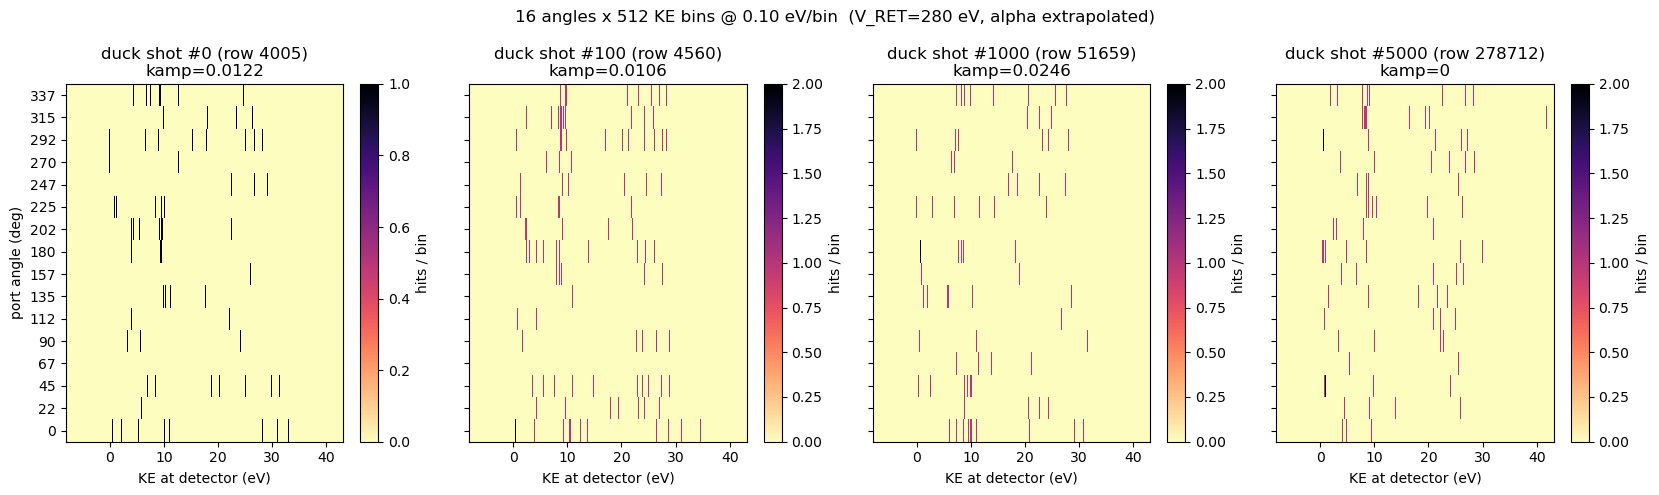

In [11]:
# Build a (16, NBINS) KE_at_det histogram for a few duck shots and plot them.
SHOT_IDX = [0, 100, 1000, 5000]     # indices into duck_rows

def shot_ke_image(shot_idx):
    """(16, NBINS) hit counts per (port angle, detector-KE bin) for one duck shot."""
    img = np.zeros((len(HSD_CHANNELS), NBINS), dtype=np.float32)
    for i, ang in enumerate(HSD_CHANNELS):
        hits_s = duck_hsd[ang][shot_idx]
        if hits_s.size == 0:
            continue
        ke = tof_to_ke(hits_s, ang)
        img[i], _ = np.histogram(ke, bins=EBIN_EDGES)
    return img

imgs = [shot_ke_image(s) for s in SHOT_IDX]

fig, axes = plt.subplots(1, len(SHOT_IDX), figsize=(4.2 * len(SHOT_IDX), 5), sharey=True)
if len(SHOT_IDX) == 1:
    axes = [axes]

for ax, s, img in zip(axes, SHOT_IDX, imgs):
    pm = ax.pcolormesh(
        EBIN_EDGES, np.arange(len(HSD_CHANNELS) + 1) - 0.5, img,
        cmap='magma_r', shading='flat',
    )
    ax.set_xlabel('KE at detector (eV)')
    ax.set_yticks(np.arange(len(HSD_CHANNELS)))
    ax.set_yticklabels([str(a) for a in HSD_CHANNELS])
    ax.set_title(f'duck shot #{s} (row {duck_rows[s]})\nkamp={duck_kamp_matched[s]:.3g}')
    fig.colorbar(pm, ax=ax, label='hits / bin')

axes[0].set_ylabel('port angle (deg)')
fig.suptitle(f'16 angles x {NBINS} KE bins @ {(EMAX-EMIN)/NBINS:.2f} eV/bin  '
             f'(V_RET={V_RET:g} eV, alpha extrapolated)')
fig.tight_layout()
plt.show()


Pooled 91,646 hits from 500 shots x 16 ports
  ToF - t0 (ns):  median=93.7, 5-95%=[2.4, 273.6]
  KE_at_det (eV): median=9.96, 5-95%=[0.56, 42.57]
  in KE window [-8.1,43.1] eV: 95.0%
  in ROI       [14.2,40.0] eV: 35.5%


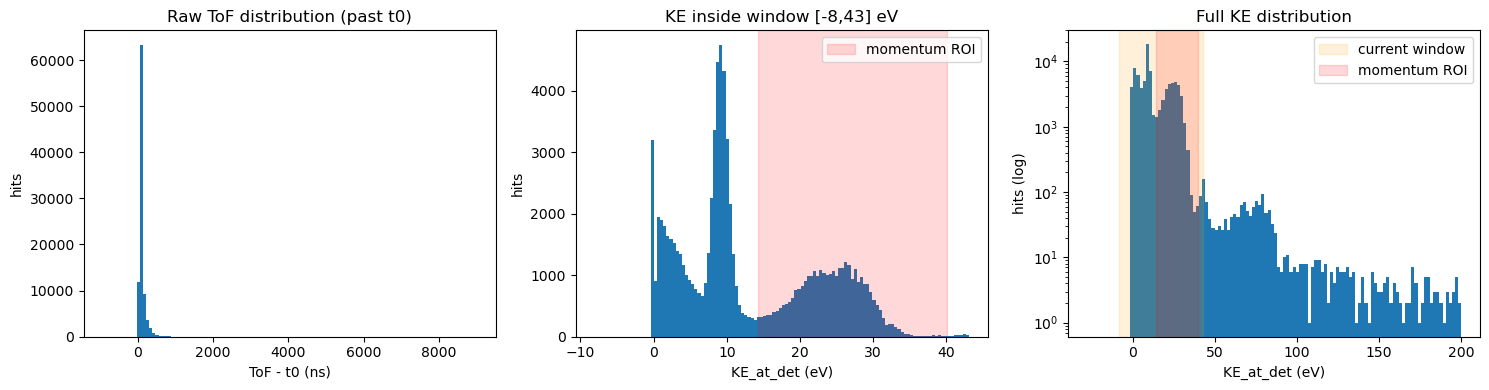

In [57]:
# Diagnostic: where do the real hits actually land?
# 1) Raw ToF distribution (all ports, all shots pooled).
# 2) Same hits converted to KE via tof_to_ke (detector frame).
# 3) Fraction of hits that fall inside [EMIN, EMAX].

# Pool a subset for speed
N_SUB = 500
sub_shots = np.arange(0, duck_rows.size, max(1, duck_rows.size // N_SUB))[:N_SUB]

all_tof_ns = []
all_ke_eV  = []
port_ke_lists = {ang: [] for ang in HSD_CHANNELS}

for s in sub_shots:
    for ang in HSD_CHANNELS:
        hits = duck_hsd[ang][s]
        if hits.size == 0:
            continue
        all_tof_ns.append((hits - t0_by_ang[ang]) * 1e9)   # ns past t0, for plotting only
        ke = tof_to_ke(hits, ang)
        all_ke_eV.append(ke)
        port_ke_lists[ang].append(ke)

all_tof_ns = np.concatenate(all_tof_ns) if all_tof_ns else np.array([])
all_ke_eV  = np.concatenate(all_ke_eV) if all_ke_eV else np.array([])

print(f"Pooled {all_tof_ns.size:,} hits from {sub_shots.size} shots x 16 ports")
print(f"  ToF - t0 (ns):  median={np.median(all_tof_ns):.1f}, "
      f"5-95%=[{np.percentile(all_tof_ns,5):.1f}, {np.percentile(all_tof_ns,95):.1f}]")
print(f"  KE_at_det (eV): median={np.median(all_ke_eV):.2f}, "
      f"5-95%=[{np.percentile(all_ke_eV,5):.2f}, {np.percentile(all_ke_eV,95):.2f}]")

in_win = (all_ke_eV >= EMIN) & (all_ke_eV < EMAX)
in_roi = (all_ke_eV >= P_ROI_KE_DET_LO) & (all_ke_eV < P_ROI_KE_DET_HI)
print(f"  in KE window [{EMIN:.1f},{EMAX:.1f}] eV: {in_win.mean()*100:.1f}%")
print(f"  in ROI       [{P_ROI_KE_DET_LO:.1f},{P_ROI_KE_DET_HI:.1f}] eV: {in_roi.mean()*100:.1f}%")

# Panels: ToF hist, KE hist zoomed on window, KE hist wide (log)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(all_tof_ns, bins=120)
axes[0].set_xlabel("ToF - t0 (ns)"); axes[0].set_ylabel("hits")
axes[0].set_title("Raw ToF distribution (past t0)")

axes[1].hist(all_ke_eV, bins=120, range=(EMIN, EMAX))
axes[1].axvspan(P_ROI_KE_DET_LO, P_ROI_KE_DET_HI, color="red", alpha=0.15, label="momentum ROI")
axes[1].set_xlabel("KE_at_det (eV)"); axes[1].set_ylabel("hits")
axes[1].set_title(f"KE inside window [{EMIN:.0f},{EMAX:.0f}] eV")
axes[1].legend()

# Wide view — include the negative KE tail that shows up when V_RET is off
lo_wide = min(-20.0, EMIN - 20)
hi_wide = max(EMAX + 20, 200.0)
axes[2].hist(all_ke_eV, bins=120, range=(lo_wide, hi_wide))
axes[2].axvspan(EMIN, EMAX, color="orange", alpha=0.15, label="current window")
axes[2].axvspan(P_ROI_KE_DET_LO, P_ROI_KE_DET_HI, color="red", alpha=0.15, label="momentum ROI")
axes[2].set_yscale("log")
axes[2].set_xlabel("KE_at_det (eV)"); axes[2].set_ylabel("hits (log)")
axes[2].set_title("Full KE distribution")
axes[2].legend()
plt.tight_layout(); plt.show()


KE_at_IP (eV): median=289.96, 5-95%=[280.56, 322.57]
p_at_IP (a.u.): median=4.616, 5-95%=[4.541, 4.869]
in friend's ROI in sample-frame momentum [4.65, 4.85] a.u.: 35.5%


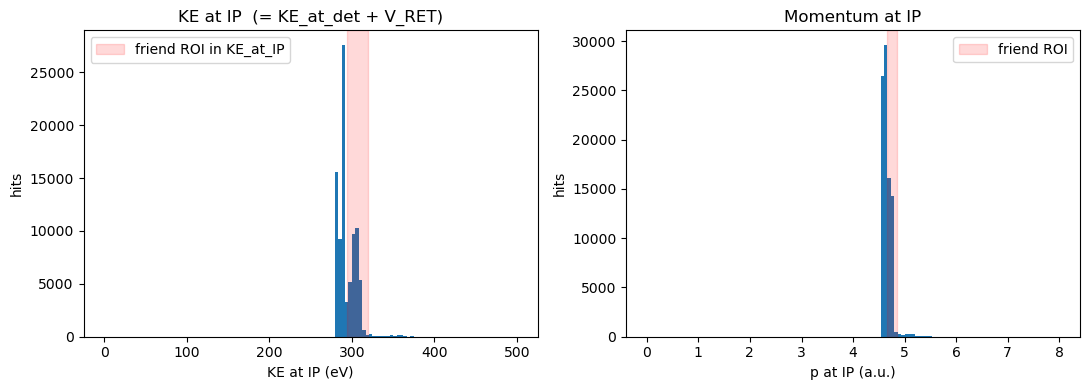

In [58]:
# Frame check: friend's ROI (4.65-4.85 a.u.) is sample-frame momentum
# (at IP, before retardation). tof_to_ke returns KE at the detector, so:
#     KE_at_IP = KE_at_det + V_RET     (V_RET is the retardation MAGNITUDE, eV)
#     p_at_IP  = sqrt(2 * KE_at_IP / E_AU)
# The peak of p_at_IP should sit inside [4.65, 4.85] a.u. if the calibration
# and V_RET are consistent with the friend's plot.

ke_at_IP = all_ke_eV + V_RET
p_at_IP  = np.sqrt(2 * np.maximum(ke_at_IP, 0) / E_AU)

print(f"KE_at_IP (eV): median={np.median(ke_at_IP):.2f}, "
      f"5-95%=[{np.percentile(ke_at_IP,5):.2f}, {np.percentile(ke_at_IP,95):.2f}]")
print(f"p_at_IP (a.u.): median={np.median(p_at_IP):.3f}, "
      f"5-95%=[{np.percentile(p_at_IP,5):.3f}, {np.percentile(p_at_IP,95):.3f}]")
in_roi_ip = (p_at_IP >= P_ROI[0]) & (p_at_IP < P_ROI[1])
print(f"in friend's ROI in sample-frame momentum [{P_ROI[0]}, {P_ROI[1]}] a.u.: "
      f"{in_roi_ip.mean()*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(ke_at_IP, bins=120, range=(0, 500))
axes[0].axvspan(P_ROI_KE_IP_LO, P_ROI_KE_IP_HI, color="red", alpha=0.15,
                label="friend ROI in KE_at_IP")
axes[0].set_xlabel("KE at IP (eV)"); axes[0].set_ylabel("hits")
axes[0].set_title("KE at IP  (= KE_at_det + V_RET)")
axes[0].legend()

axes[1].hist(p_at_IP, bins=120, range=(0, 8))
axes[1].axvspan(P_ROI[0], P_ROI[1], color="red", alpha=0.15, label="friend ROI")
axes[1].set_xlabel("p at IP (a.u.)"); axes[1].set_ylabel("hits")
axes[1].set_title("Momentum at IP")
axes[1].legend()
plt.tight_layout(); plt.show()


In [59]:
# Sim-comparable Ximg for duck shots.
#
# Sim mrco_h5 was built by src/data_processing/universal_cookiesimslim_processor.py:
# a MinMaxScaler(feature_range=(0,1)) is fit PER-BIN (per column of the 16x512
# image) across ALL sim TRAINING shots, then every sim image is transformed
# with that fitted scaler.
#
# To make a real duck Ximg directly comparable to sim, we apply *that same
# scaler* here — fitting a fresh one on real data would put real & sim on
# different axes even though both are in [0, 1].
#
# The persisted .joblib on disk is for the 320-bin (cropped) sim variant
# (cookiebox_ml_320_processed/). Our KE grid is 512 bins, so we fit the
# scaler on the fly from the 512-bin sim training set (mrco_h5/train/).
# For a 320-bin comparison, swap SIM_TRAIN_GLOB and SIM_XIMG_SCALER below.

import os, glob, joblib
from sklearn.preprocessing import MinMaxScaler

SIM_TRAIN_GLOB  = '/sdf/home/m/miaed/tmo_exp/tmo101347625/scratch/miaed_mnis_data/mrco_h5/train/*.h5'
SIM_XIMG_SCALER = (
    '/sdf/home/m/miaed/tmo_exp/tmo101347625/scratch/miaed_mnis_data/'
    'cookiebox_ml_320_processed/train/min_max_scaler_320_ximg.joblib'
)

# Per-port ToF gate. Anything outside the calibrated KE window maps to
# non-physical energies; skip those hits before histogramming.
TOF_KE_GATE_MARGIN = 20.0  # eV — accept hits within [EMIN-margin, EMAX+margin]
tof_gate = {}
for ang in HSD_CHANNELS:
    t0 = t0_by_ang[ang]; A = alpha_at_vret[ang]
    ke_hi = max(EMAX + TOF_KE_GATE_MARGIN, 1.0)
    ke_lo = max(EMIN - TOF_KE_GATE_MARGIN, 1e-3)
    t_lo = t0 + np.sqrt(A / ke_hi)   # small dt past t0 -> high KE
    t_hi = t0 + np.sqrt(A / ke_lo)   # large dt past t0 -> low KE
    tof_gate[ang] = (t_lo, t_hi)

def duck_shot_ximg_raw(shot_idx):
    """(16, NBINS) raw hit counts on the KE grid, no scaling. Applies ToF gate."""
    img = np.zeros((len(HSD_CHANNELS), NBINS), dtype=np.float32)
    for i, ang in enumerate(HSD_CHANNELS):
        hits_s = duck_hsd[ang][shot_idx]
        if hits_s.size == 0:
            continue
        t_lo, t_hi = tof_gate[ang]
        good = (hits_s > t_lo) & (hits_s < t_hi)
        if not good.any():
            continue
        ke = tof_to_ke(hits_s[good], ang)
        img[i], _ = np.histogram(ke, bins=EBIN_EDGES)
    return img

print(f"Building raw duck Ximg for {duck_rows.size} shots...")
duck_ximg_raw = np.stack([duck_shot_ximg_raw(s) for s in range(duck_rows.size)])
print(f"  shape: {duck_ximg_raw.shape}, dtype: {duck_ximg_raw.dtype}, "
      f"raw range [{duck_ximg_raw.min():.3g}, {duck_ximg_raw.max():.3g}]")

# --- Resolve the scaler ---
# 1. Try the persisted .joblib. Use only if its n_features_in_ matches NBINS.
# 2. Otherwise, reproduce the training-time scaler by MinMax-fitting on all
#    sim training shots at NBINS resolution.
ximg_scaler = None
scaler_source = None
if os.path.exists(SIM_XIMG_SCALER):
    _cand = joblib.load(SIM_XIMG_SCALER)
    if _cand.n_features_in_ == NBINS:
        ximg_scaler = _cand
        scaler_source = f'persisted sim scaler ({os.path.basename(SIM_XIMG_SCALER)})'
    else:
        print(f"  NOTE: persisted scaler has {_cand.n_features_in_} bins != NBINS={NBINS} "
              f"(that .joblib is for the 320-bin cropped sim). "
              f"Falling back to fitting from sim training set.")

if ximg_scaler is None:
    sim_train_files = sorted(glob.glob(SIM_TRAIN_GLOB))
    assert sim_train_files, f'no sim training files under {SIM_TRAIN_GLOB}'
    print(f"  Fitting MinMaxScaler from {len(sim_train_files)} sim training files "
          f"(reproducing training-time preprocessing)...")
    ximg_scaler = MinMaxScaler(feature_range=(0, 1))
    n_seen = 0
    for fp in sim_train_files:
        with h5py.File(fp, 'r') as hf:
            for key in hf.keys():
                img = hf[key]['Ximg'][:]
                if img.shape[1] != NBINS:
                    raise AssertionError(
                        f'sim Ximg has {img.shape[1]} bins in {fp}, but NBINS={NBINS}.'
                    )
                ximg_scaler.partial_fit(img)
                n_seen += 1
    scaler_source = f'fit from sim training ({n_seen} shots, NBINS={NBINS})'

duck_ximg = ximg_scaler.transform(duck_ximg_raw.reshape(-1, NBINS)).reshape(duck_ximg_raw.shape)
duck_ximg = np.clip(duck_ximg, 0.0, 1.0).astype(np.float32)
print(f"  scaler: {scaler_source}")
print(f"  after scaling: range [{duck_ximg.min():.3g}, {duck_ximg.max():.3g}], "
      f"mean={duck_ximg.mean():.3g}, nonzero fraction={(duck_ximg>0).mean():.3f}")
print(f"  (sim mrco_h5 typically: mean~2.5e-3, nonzero fraction~2.4%, max~0.33)")

def duck_shot_ximg(shot_idx):
    """Sim-comparable (16, NBINS) Ximg for one duck shot (post-scaling)."""
    return duck_ximg[shot_idx]


Building raw duck Ximg for 26221 shots...
  shape: (26221, 16, 512), dtype: float32, raw range [0, 16]
  NOTE: persisted scaler has 320 bins != NBINS=512 (that .joblib is for the 320-bin cropped sim). Falling back to fitting from sim training set.
  Fitting MinMaxScaler from 30 sim training files (reproducing training-time preprocessing)...
  scaler: fit from sim training (245760 shots, NBINS=512)
  after scaling: range [0, 1], mean=0.0203, nonzero fraction=0.020
  (sim mrco_h5 typically: mean~2.5e-3, nonzero fraction~2.4%, max~0.33)


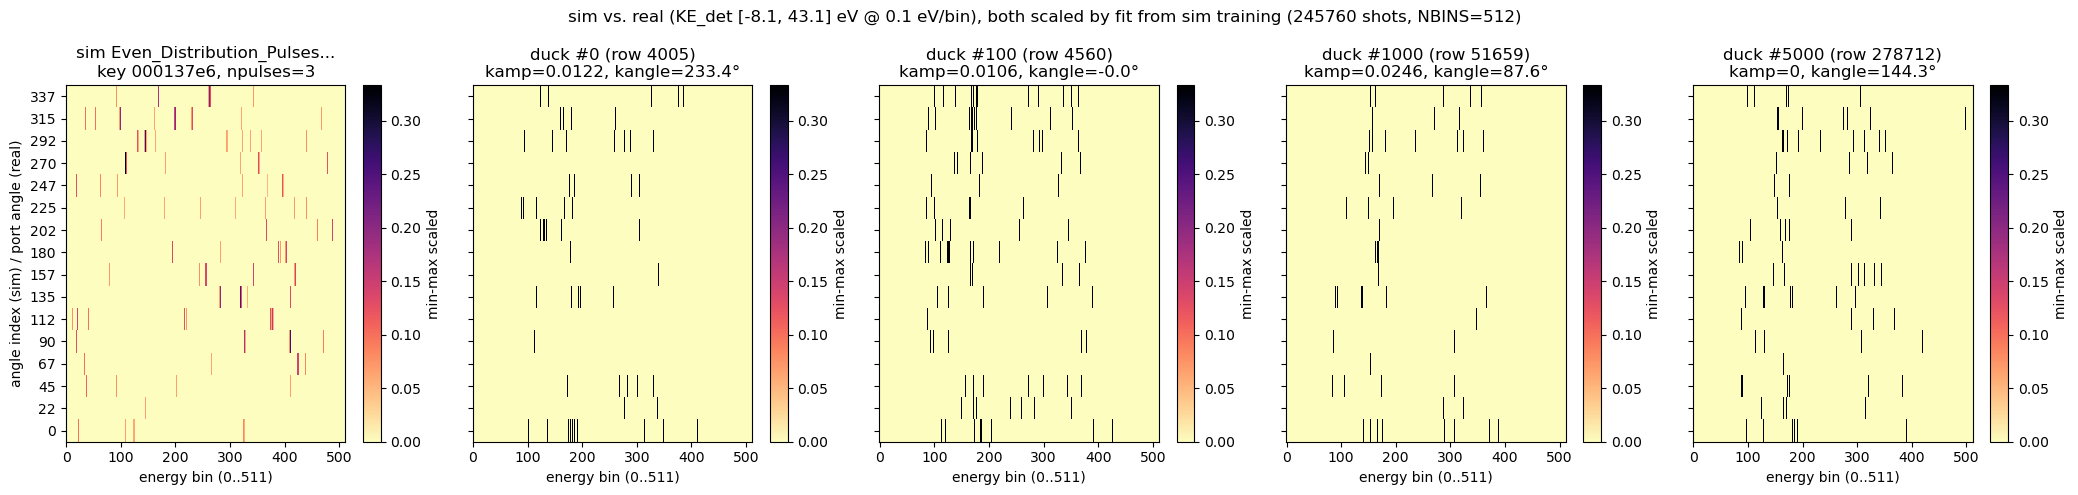

In [60]:
# Side-by-side: real duck-shot Ximg (KE window centered on ROI) vs. a
# simulated Ximg from mrco_h5/train — same shape (16, 512), both scaled by
# the sim training MinMaxScaler.
import os, glob

SIM_GLOB = '/sdf/home/m/miaed/tmo_exp/tmo101347625/scratch/miaed_mnis_data/mrco_h5/train/*.h5'
sim_files = sorted(glob.glob(SIM_GLOB))
assert sim_files, f'no sim files under {SIM_GLOB}'

# Pull one sim Ximg
with h5py.File(sim_files[0], 'r') as hf:
    sim_key = next(iter(hf.keys()))
    sim_img = np.array(hf[sim_key]['Ximg'])
    sim_npulses = int(hf[sim_key].attrs['npulses'])
    sim_energies = np.array(hf[sim_key].attrs['energies'])

# vmax that keeps sim structure visible (sim max ~ 0.33 typically).
VMAX_PLOT = max(float(sim_img.max()), 0.3)

COMPARE_SHOTS = [0, 100, 1000, 5000]
duck_imgs = [duck_shot_ximg(s) for s in COMPARE_SHOTS]

n = 1 + len(COMPARE_SHOTS)
fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 5), sharey=True)

def show(ax, img, title):
    pm = ax.pcolormesh(
        np.arange(img.shape[1] + 1) - 0.5,
        np.arange(img.shape[0] + 1) - 0.5,
        img, cmap='magma_r', shading='flat', vmin=0, vmax=VMAX_PLOT,
    )
    ax.set_xlabel('energy bin (0..511)')
    ax.set_yticks(np.arange(img.shape[0]))
    if img.shape[0] == len(HSD_CHANNELS):
        ax.set_yticklabels([str(a) for a in HSD_CHANNELS])
    ax.set_title(title)
    fig.colorbar(pm, ax=ax, label='min-max scaled')

show(axes[0], sim_img,
     f'sim {os.path.basename(sim_files[0])[:24]}...\n'
     f'key {sim_key[:8]}, npulses={sim_npulses}')
for ax, s, img in zip(axes[1:], COMPARE_SHOTS, duck_imgs):
    show(ax, img, f'duck #{s} (row {duck_rows[s]})\n'
                  f'kamp={duck_kamp_matched[s]:.3g}, '
                  f'kangle={np.degrees(duck_kangle_matched[s]):.1f}°')

axes[0].set_ylabel('angle index (sim) / port angle (real)')
fig.suptitle(f'sim vs. real (KE_det [{EMIN:.1f}, {EMAX:.1f}] eV @ {ESTEP} eV/bin), '
             f'both scaled by {scaler_source}')
fig.tight_layout()
plt.show()


top 50 shots: total hits range [362, 415], median=377


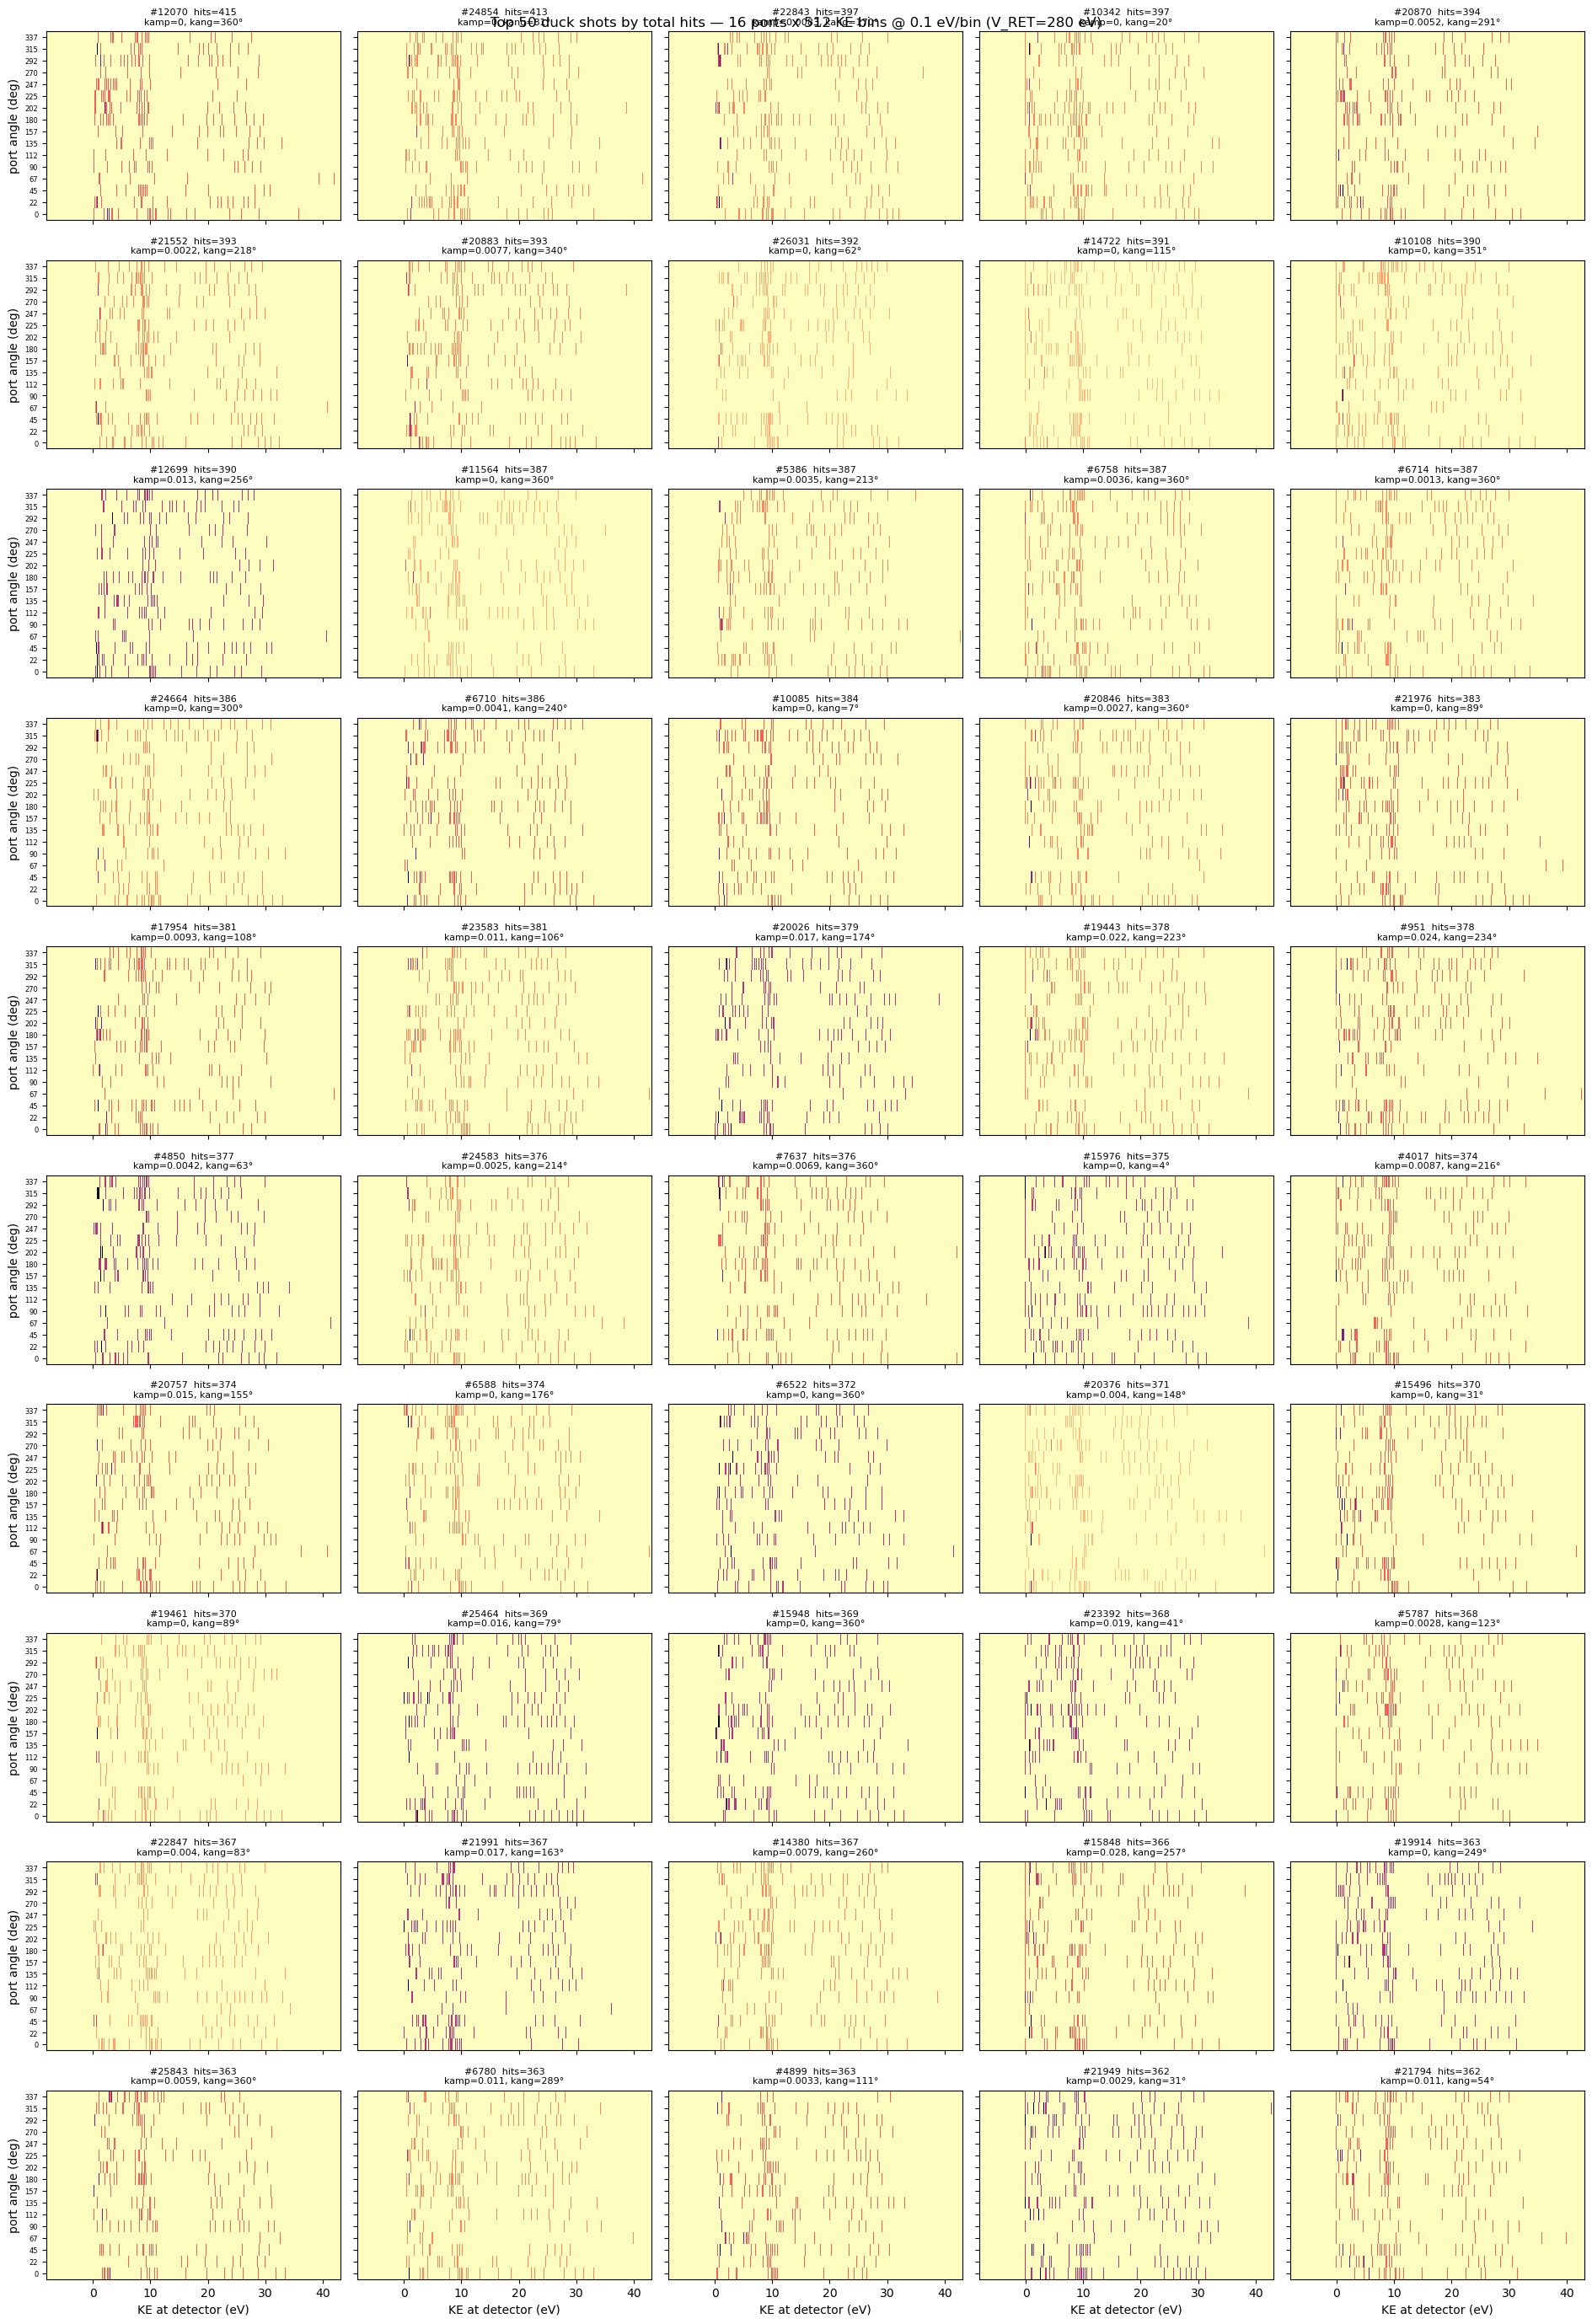

In [61]:
# Top-50 duck shots by total hit count (summed across all 16 ports),
# plotted as (16, NBINS) KE_at_det histograms on the same KE grid used above.
TOP_N = 50

# Total hits per shot across all 16 channels — cheap: just sum array lengths.
hits_per_shot = np.zeros(duck_rows.size, dtype=np.int64)
for ang in HSD_CHANNELS:
    hits_per_shot += np.array([a.size for a in duck_hsd[ang]], dtype=np.int64)

top_idx = np.argsort(hits_per_shot)[::-1][:TOP_N]
print(f'top {TOP_N} shots: total hits range [{hits_per_shot[top_idx[-1]]}, {hits_per_shot[top_idx[0]]}], '
      f'median={int(np.median(hits_per_shot[top_idx]))}')

ncols = 5
nrows = int(np.ceil(TOP_N / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.8 * ncols, 2.8 * nrows), sharex=True, sharey=True)
axes = np.atleast_2d(axes)

for k, s in enumerate(top_idx):
    ax = axes[k // ncols, k % ncols]
    img = shot_ke_image(int(s))
    pm = ax.pcolormesh(
        EBIN_EDGES, np.arange(len(HSD_CHANNELS) + 1) - 0.5, img,
        cmap='magma_r', shading='flat',
    )
    ax.set_title(f'#{int(s)}  hits={int(hits_per_shot[s])}\n'
                 f'kamp={duck_kamp_matched[s]:.2g}, '
                 f'kang={np.degrees(duck_kangle_matched[s]):.0f}°',
                 fontsize=8)
    ax.set_yticks(np.arange(len(HSD_CHANNELS)))
    ax.set_yticklabels([str(a) for a in HSD_CHANNELS], fontsize=6)

for k in range(TOP_N, nrows * ncols):
    axes[k // ncols, k % ncols].axis('off')

for ax in axes[-1, :]:
    ax.set_xlabel('KE at detector (eV)')
for ax in axes[:, 0]:
    ax.set_ylabel('port angle (deg)')

fig.suptitle(f'Top {TOP_N} duck shots by total hits — 16 ports x {NBINS} KE bins @ '
             f'{ESTEP} eV/bin (V_RET={V_RET:g} eV)')
fig.tight_layout()
plt.show()


top 50 shots by kamp: kamp range [0.0346, 0.049], median=0.0384
  hits/shot for these: median=143, range [79, 276]


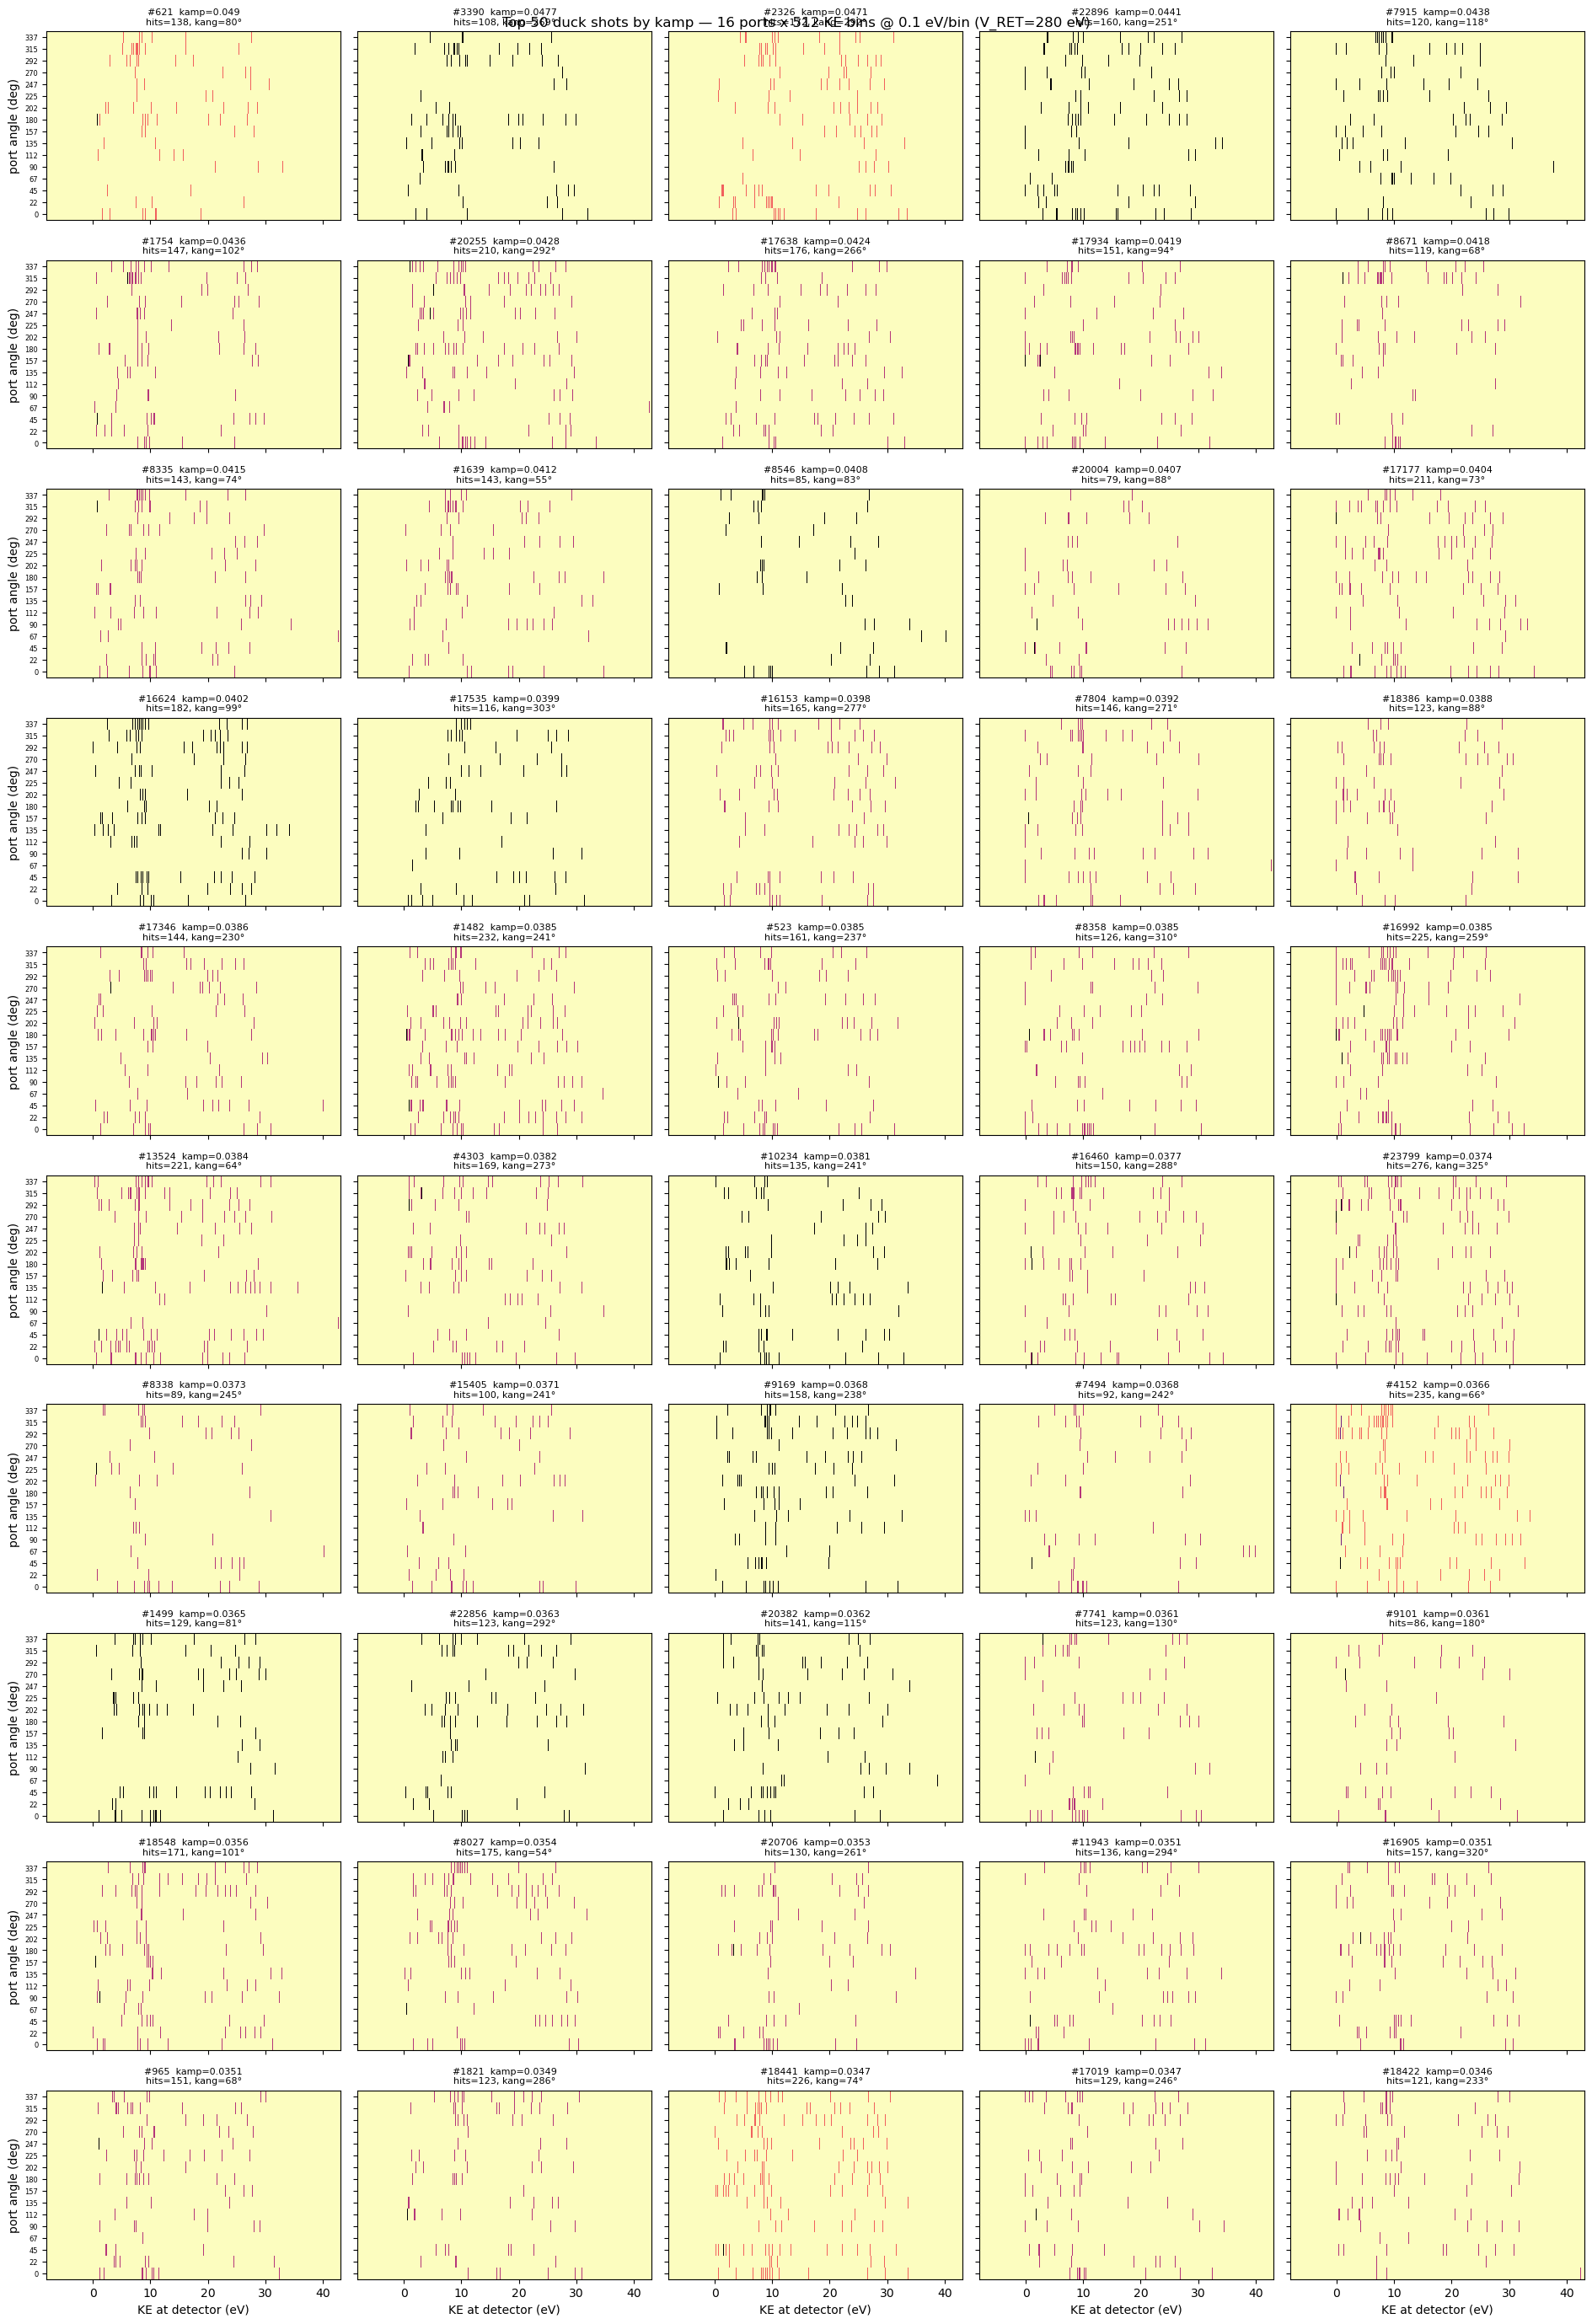

In [62]:
# Top-50 duck shots by kick amplitude (kamp) — the river-side streaking
# strength. High-kamp shots are where the streak signal is strongest and
# where the phase heads should have the most to work with. Contrast against
# the top-by-hits view above: those select on total electron yield, this
# selects on streak visibility.
TOP_N_KAMP = 50

top_idx_kamp = np.argsort(duck_kamp_matched)[::-1][:TOP_N_KAMP]
print(f'top {TOP_N_KAMP} shots by kamp: '
      f'kamp range [{duck_kamp_matched[top_idx_kamp[-1]]:.3g}, '
      f'{duck_kamp_matched[top_idx_kamp[0]]:.3g}], '
      f'median={np.median(duck_kamp_matched[top_idx_kamp]):.3g}')
print(f'  hits/shot for these: median={int(np.median(hits_per_shot[top_idx_kamp]))}, '
      f'range [{int(hits_per_shot[top_idx_kamp].min())}, '
      f'{int(hits_per_shot[top_idx_kamp].max())}]')

ncols = 5
nrows = int(np.ceil(TOP_N_KAMP / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.8 * ncols, 2.8 * nrows), sharex=True, sharey=True)
axes = np.atleast_2d(axes)

for k, s in enumerate(top_idx_kamp):
    ax = axes[k // ncols, k % ncols]
    img = shot_ke_image(int(s))
    pm = ax.pcolormesh(
        EBIN_EDGES, np.arange(len(HSD_CHANNELS) + 1) - 0.5, img,
        cmap='magma_r', shading='flat',
    )
    ax.set_title(f'#{int(s)}  kamp={duck_kamp_matched[s]:.3g}\n'
                 f'hits={int(hits_per_shot[s])}, '
                 f'kang={np.degrees(duck_kangle_matched[s]):.0f}°',
                 fontsize=8)
    ax.set_yticks(np.arange(len(HSD_CHANNELS)))
    ax.set_yticklabels([str(a) for a in HSD_CHANNELS], fontsize=6)

for k in range(TOP_N_KAMP, nrows * ncols):
    axes[k // ncols, k % ncols].axis('off')

for ax in axes[-1, :]:
    ax.set_xlabel('KE at detector (eV)')
for ax in axes[:, 0]:
    ax.set_ylabel('port angle (deg)')

fig.suptitle(f'Top {TOP_N_KAMP} duck shots by kamp — 16 ports x {NBINS} KE bins @ '
             f'{ESTEP} eV/bin (V_RET={V_RET:g} eV)')
fig.tight_layout()
plt.show()


bottom 50 shots by gmd across all 1,252,313 preproc rows:
  gmd range [0.244, 0], median=0.244
  designation: duck=0, goose=0, none=50


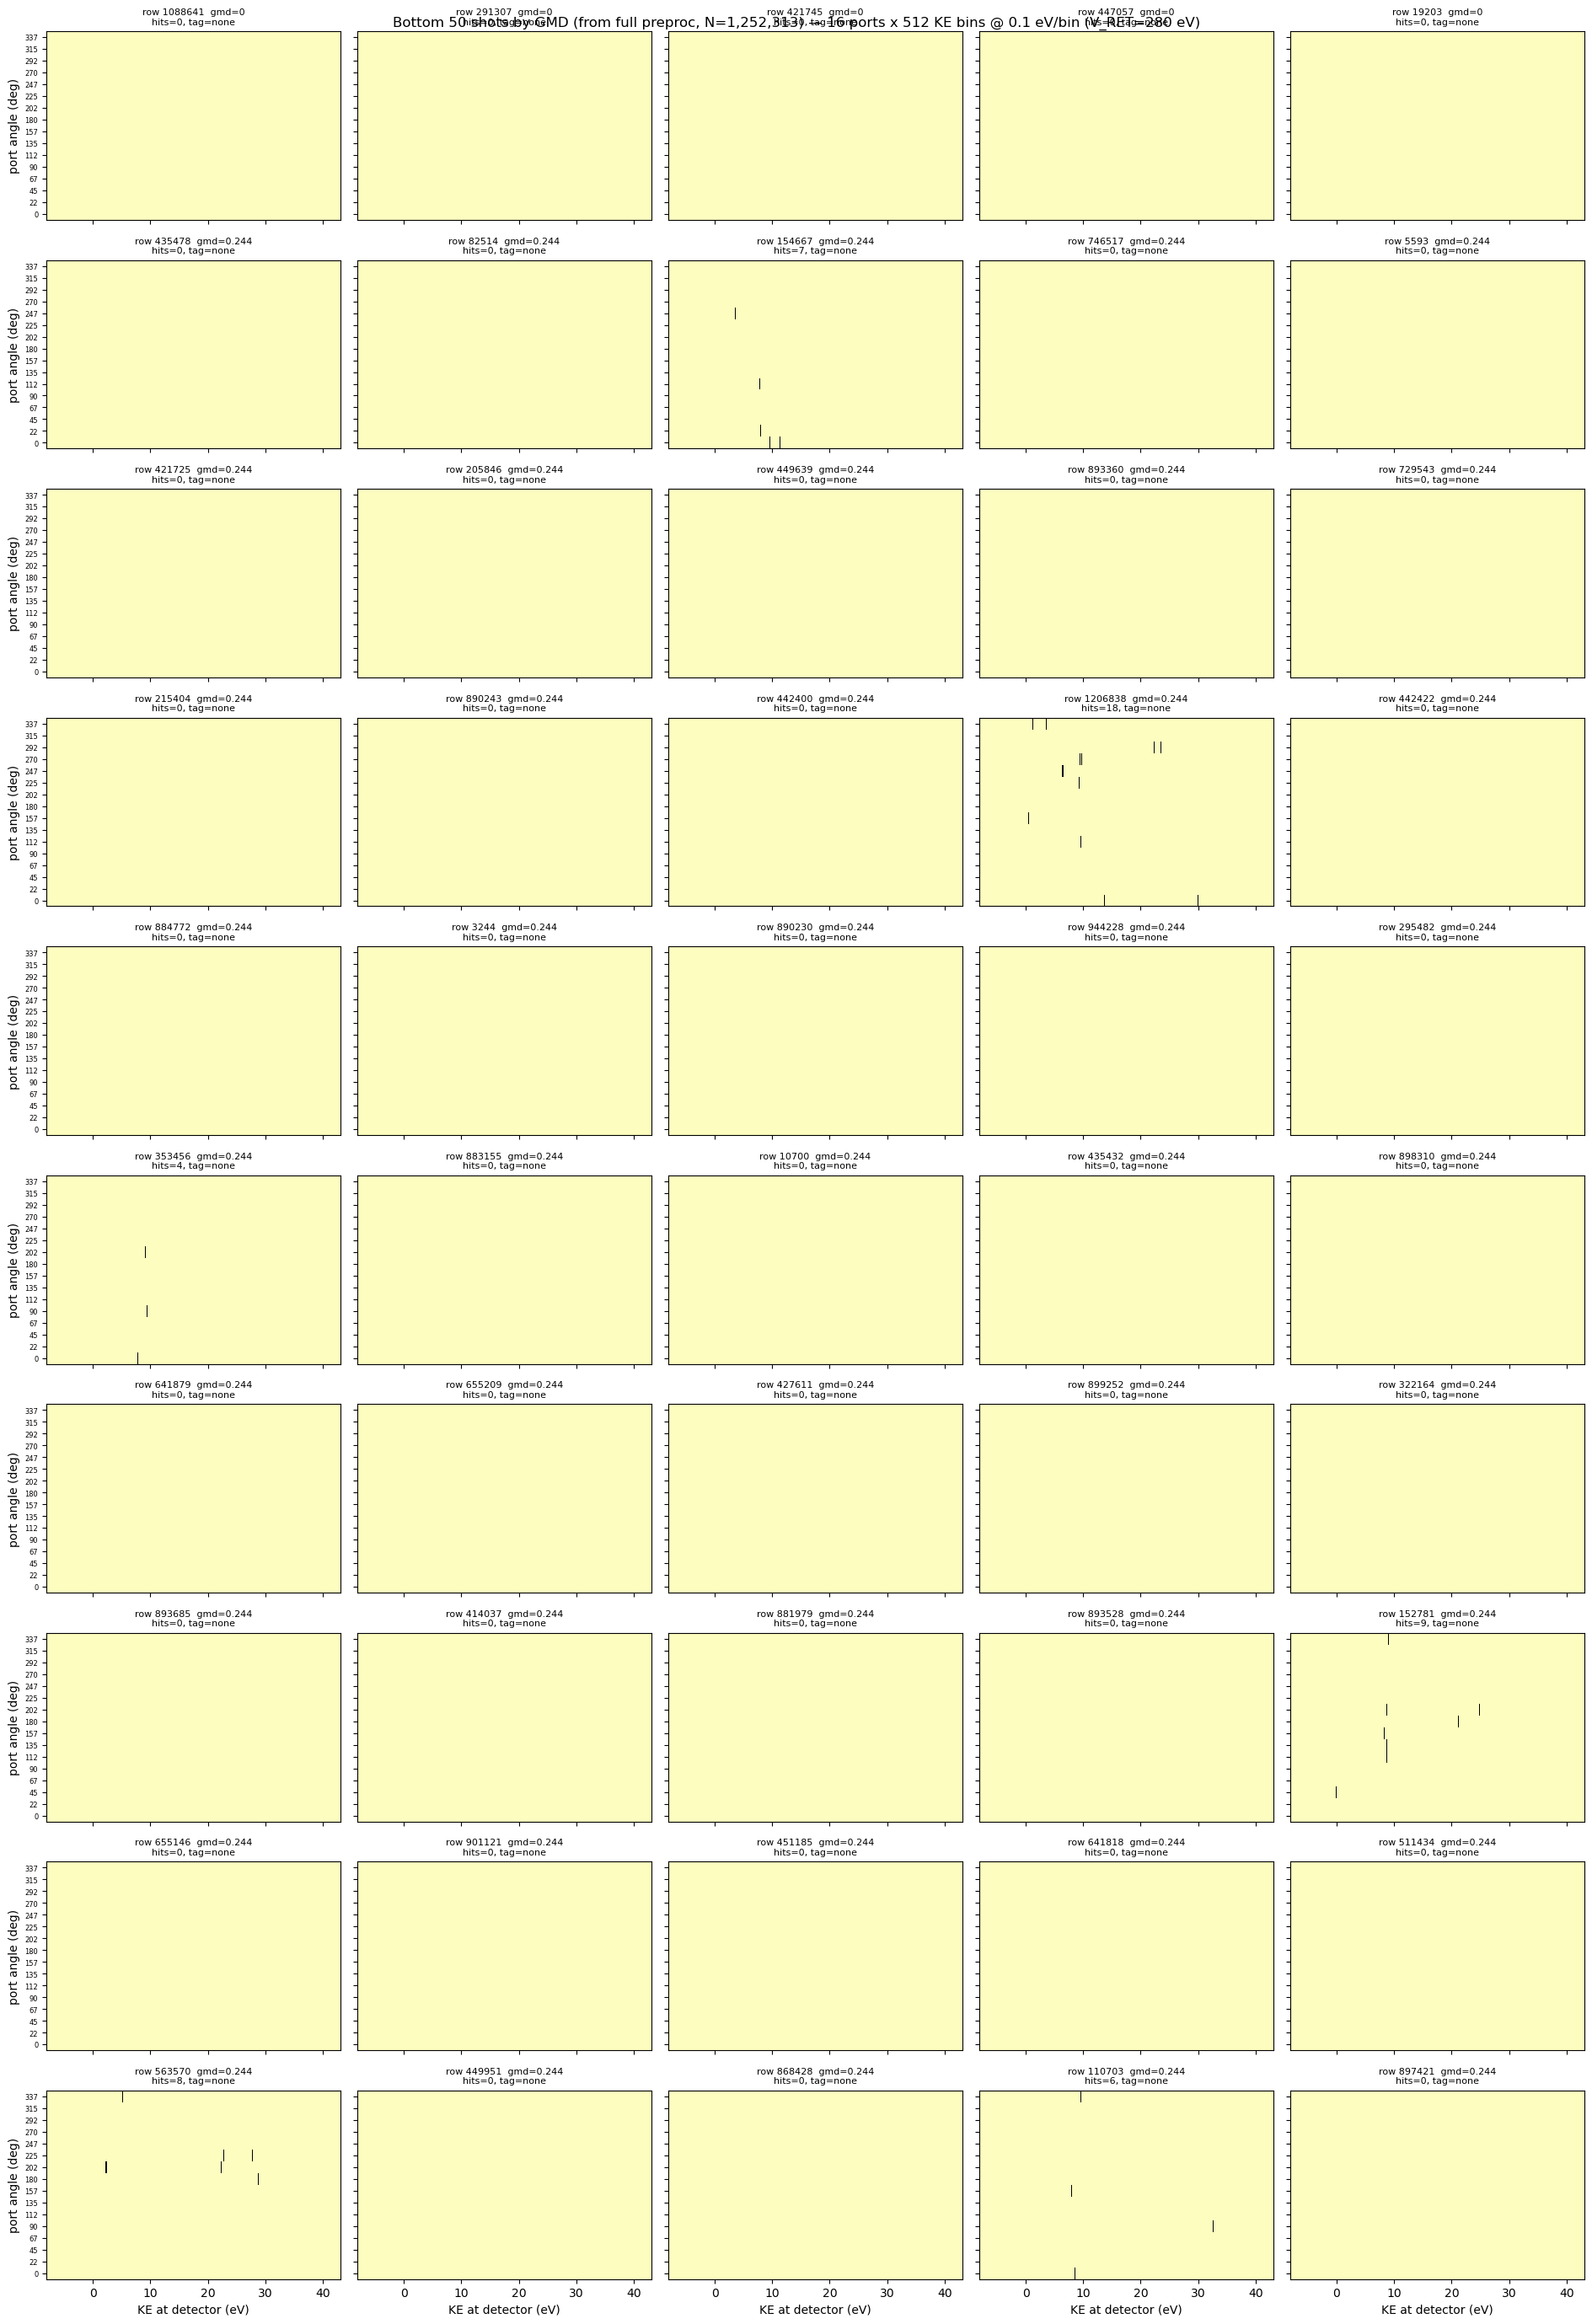

In [12]:
# Bottom-50 shots by GMD energy — pulled directly from the PREPROC file
# (all 1.25M shots), NOT the duck-matched subset. Only ~26k rows in
# preproc have a duck designation (2k goose), so most low-gmd shots won't
# have one — we tag each shot as duck/goose/none for context.

BOT_N_GMD = 50

# 1) All-preproc GMD — find the 50 lowest-gmd rows across the whole file.
with h5py.File(PREPROC_PATH, 'r') as pf:
    all_gmd = pf['gmd_energy'][:]

bot_rows = np.argsort(all_gmd)[:BOT_N_GMD]         # row indices into preproc
bot_rows_sorted = np.sort(bot_rows)                # h5 fancy-indexing needs sorted, unique

# 2) Duck/goose designation (if any) per selected row.
#    duck_rows / duck_ts_matched were computed earlier from the river file.
with h5py.File(RIVER_PATH, 'r') as rf:
    goose_ts_all = rf['goose_timestamps'][:]

with h5py.File(PREPROC_PATH, 'r') as pf:
    bot_ts = pf['timestamp'][bot_rows_sorted]

duck_ts_set  = set(duck_ts_matched.tolist())
goose_ts_set = set(goose_ts_all.tolist())
tag_by_row = {}
for r, ts in zip(bot_rows_sorted, bot_ts):
    if ts in duck_ts_set:
        tag_by_row[int(r)] = 'duck'
    elif ts in goose_ts_set:
        tag_by_row[int(r)] = 'goose'
    else:
        tag_by_row[int(r)] = 'none'

n_duck  = sum(t == 'duck'  for t in tag_by_row.values())
n_goose = sum(t == 'goose' for t in tag_by_row.values())
print(f'bottom {BOT_N_GMD} shots by gmd across all {all_gmd.size:,} preproc rows:')
print(f'  gmd range [{all_gmd[bot_rows[-1]]:.3g}, {all_gmd[bot_rows[0]]:.3g}], '
      f'median={np.median(all_gmd[bot_rows]):.3g}')
print(f'  designation: duck={n_duck}, goose={n_goose}, none={BOT_N_GMD - n_duck - n_goose}')

# 3) Load HSD hits for the selected rows (fresh, not from duck_hsd cache).
bot_hsd = {}
with h5py.File(PREPROC_PATH, 'r') as pf:
    for ch in HSD_CHANNELS:
        lens = pf[f'var_hsd_hf_times_{ch}_len'][:]
        flat = pf[f'var_hsd_hf_times_{ch}'][:]
        ends = np.cumsum(lens); starts = ends - lens
        bot_hsd[ch] = {int(r): flat[starts[r]:ends[r]] for r in bot_rows_sorted}

def bot_ke_image(row):
    img = np.zeros((len(HSD_CHANNELS), NBINS), dtype=np.float32)
    for i, ang in enumerate(HSD_CHANNELS):
        hits = bot_hsd[ang][int(row)]
        if hits.size == 0:
            continue
        ke = tof_to_ke(hits, ang)
        img[i], _ = np.histogram(ke, bins=EBIN_EDGES)
    return img

# 4) Plot in ascending-gmd order (same layout as the top-N panels above).
plot_order = bot_rows                              # already argsort'd ascending by gmd

ncols = 5
nrows = int(np.ceil(BOT_N_GMD / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.8 * ncols, 2.8 * nrows), sharex=True, sharey=True)
axes = np.atleast_2d(axes)

for k, r in enumerate(plot_order):
    ax = axes[k // ncols, k % ncols]
    img = bot_ke_image(int(r))
    ax.pcolormesh(
        EBIN_EDGES, np.arange(len(HSD_CHANNELS) + 1) - 0.5, img,
        cmap='magma_r', shading='flat',
    )
    tag = tag_by_row[int(r)]
    n_hits = int(sum(bot_hsd[ang][int(r)].size for ang in HSD_CHANNELS))
    ax.set_title(f'row {int(r)}  gmd={all_gmd[r]:.3g}\n'
                 f'hits={n_hits}, tag={tag}',
                 fontsize=8)
    ax.set_yticks(np.arange(len(HSD_CHANNELS)))
    ax.set_yticklabels([str(a) for a in HSD_CHANNELS], fontsize=6)

for k in range(BOT_N_GMD, nrows * ncols):
    axes[k // ncols, k % ncols].axis('off')

for ax in axes[-1, :]:
    ax.set_xlabel('KE at detector (eV)')
for ax in axes[:, 0]:
    ax.set_ylabel('port angle (deg)')

fig.suptitle(f'Bottom {BOT_N_GMD} shots by GMD (from full preproc, N={all_gmd.size:,}) — '
             f'16 ports x {NBINS} KE bins @ {ESTEP} eV/bin (V_RET={V_RET:g} eV)')
fig.tight_layout()
plt.show()
